# SelfCheckGPT — Comparison with the NLI method

**What this notebook does.** We implement the **SelfCheck-NLI** detector from scratch and reproduce the main benchmark numbers on `wiki_bio_gpt3_hallucination`. We use the **mean** aggregator with **N = 20** samples, and `cross-encoder/nli-deberta-v3-large`.

> **Runtime.** NLI scoring requires ≈ 38k DeBERTa-large forward passes. **A GPU runtime is strongly recommended**. On CPU, set `MAX_PASSAGES` to a small number for a quick smoke run.

## 1. Setup

In [10]:
%pip install --quiet datasets scikit-learn scipy matplotlib transformers sentencepiece protobuf tqdm

In [11]:
import math, re, random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from datasets import load_dataset
from sklearn.metrics import average_precision_score
from scipy.stats import pearsonr, spearmanr

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

device = ('cuda' if torch.cuda.is_available()
          else 'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
          else 'cpu')
print('device:', device)

MAX_PASSAGES = None if device != 'cpu' else 15

device: cuda


## 2. Dataset

`potsawee/wiki_bio_gpt3_hallucination` (the official benchmark, 238 passages):
- `gpt3_text` — a biography generated by `text-davinci-003` from a Wikipedia subject;
- `gpt3_sentences` — the passage split into sentences;
- `annotation` — per-sentence human label in `{accurate, minor_inaccurate, major_inaccurate}`;
- `gpt3_text_samples` — 20 stochastic samples from the same prompt at $T = 1.0$ (this is the only signal the detector is allowed to use).

In [12]:
ds = load_dataset('potsawee/wiki_bio_gpt3_hallucination', split='evaluation')
print(f'passages: {len(ds)}')
print(f'sentences: {sum(len(ex["gpt3_sentences"]) for ex in ds)}')
from collections import Counter as _C
label_dist = _C(a for ex in ds for a in ex['annotation'])
print('label distribution:', dict(label_dist))

passages: 238
sentences: 1908
label distribution: {'major_inaccurate': 761, 'minor_inaccurate': 631, 'accurate': 516}


In [13]:
ex = ds[0]
print(ex['gpt3_text'][:400], '...\n')
print('one of the 20 stochastic samples:')
print(ex['gpt3_text_samples'][0][:400], '...')

John Russell Reynolds (1820–1876) was an English lawyer, judge, and author. He was born in London, the son of a barrister, and was educated at Eton College and Trinity College, Cambridge. He was called to the bar in 1845, and became a Queen's Counsel in 1859. He was appointed a judge of the Court of Common Pleas in 1867, and was knighted in 1871.

Reynolds was a prolific author, writing on a wide  ...

one of the 20 stochastic samples:
John Russell Reynolds (1 November 1829  – 11 March 1907) was an English lexicographer, editor and author. Born in London, he was the eldest son of the first Lord Ogmore, and was educated at Trinity College, Oxford, where he graduated B.A. in 1852 and became a Fellow in 1854. He was president of Magdalen Hall from 1864 to 1884, and from 1864 to 1883 was assistant-editor to the Oxford English Dictio ...


## 3. SelfCheck-NLI — implementation

The paper specifies *DeBERTa-v3-large fine-tuned on MNLI*. We use `cross-encoder/nli-deberta-v3-large`, which is that exact architecture with a proper **3-class** head {contradiction, entailment, neutral} and named labels. Dropping the neutral class and renormalizing is essential.

In [14]:
NLI_MODEL = 'cross-encoder/nli-deberta-v3-large'

nli_tok = AutoTokenizer.from_pretrained(NLI_MODEL)
nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL).to(device).eval()

id2label = {int(k): v.lower() for k, v in nli_model.config.id2label.items()}
ENT_IDX = next(i for i, l in id2label.items() if 'entail' in l)
CON_IDX = next(i for i, l in id2label.items() if 'contradict' in l)
print('id2label:', id2label, '| num_labels=', nli_model.config.num_labels,
      '| entail=', ENT_IDX, 'contradict=', CON_IDX)

config.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

id2label: {0: 'contradiction', 1: 'entailment', 2: 'neutral'} | num_labels= 3 | entail= 1 contradict= 0


In [15]:
@torch.no_grad()
def contradiction_probs(premises, hypotheses, batch_size=16):
    # Compute contradiction probabilities for pairs of premises and hypotheses, in batches.
    out = []
    for start in range(0, len(premises), batch_size):
        p = premises[start:start + batch_size]
        h = hypotheses[start:start + batch_size]
        enc = nli_tok(p, h, return_tensors='pt', padding=True,
                      truncation=True, max_length=512).to(device)
        logits = nli_model(**enc).logits
        two = logits[:, [ENT_IDX, CON_IDX]]   # keep only entail + contradict
        pc = torch.softmax(two, dim=-1)[:, 1]
        out.extend(pc.float().cpu().tolist())
    return out


def selfcheck_nli(response_sentences, samples, batch_size=16,
                  aggregator='mean', direction='premise_sample'):
    # Compute contradiction scores for all sentence-sample pairs, then aggregate per sentence.
    N = len(samples)
    premises, hypotheses = [], []
    for ri in response_sentences:
        for sn in samples:
            if direction == 'premise_sample':   # premise = sample, hypothesis = sentence
                premises.append(sn); hypotheses.append(ri)
            else:                                
                premises.append(ri); hypotheses.append(sn)
    flat = contradiction_probs(premises, hypotheses, batch_size=batch_size)
    scores = []
    for idx in range(len(response_sentences)):
        block = flat[idx * N:(idx + 1) * N]
        if not block:
            scores.append(0.0)
        else:
            scores.append(float(np.mean(block)) if aggregator == 'mean' else float(np.max(block)))
    return scores

**Sanity check.** A passage with mixed human labels: the `accurate` sentence should land toward the bottom of the contradiction-score distribution, the `major_inaccurate` ones toward the top.

In [16]:
for i, ex in enumerate(ds):
    if 'accurate' in ex['annotation'] and 'major_inaccurate' in ex['annotation']:
        print(f'passage #{i}\n')
        sc = selfcheck_nli(ex['gpt3_sentences'], ex['gpt3_text_samples'])
        for s, score, a in zip(ex['gpt3_sentences'], sc, ex['annotation']):
            tag = {'accurate':'✓ fact', 'minor_inaccurate':'~ minor', 'major_inaccurate':'✗ MAJOR'}[a]
            print(f'  [{tag:>8}] {score:4.2f}  {s[:90]}')
        break

passage #2

  [ ~ minor] 0.43  Rick Mahler (born Richard Alan Mahler on April 18, 1957 in Atlanta, Georgia) was an Americ
  [ ~ minor] 0.30  He was a two-time All-Star and won the National League (NL) ERA title in 1985.
  [  ✓ fact] 0.69  Mahler was drafted by the Braves in the first round of the 1975 amateur draft.
  [ ~ minor] 0.40  He made his major league debut with the Braves in 1978, and was a member of the team's sta
  [ ~ minor] 0.57  He was an All-Star in 1983 and 1985, and won the NL ERA title in 1985 with a 2.87 ERA.
  [ ~ minor] 0.75  He was traded to the Reds in 1984, and then to the Expos in 1986.
  [ ✗ MAJOR] 0.92  He was traded to the Twins in 1989, and finished his career with them in 1990.
  [ ~ minor] 0.23  Mahler was known for his durability, as he pitched over 200 innings in six consecutive sea
  [ ~ minor] 0.60  He finished his career with a record of 119–121, a 3.90 ERA, and 1,07


## 4. Main result — reproduction on the full benchmark

We follow the paper's protocol:
- **Sentence-level**: binarize annotations as *NonFact* (anything ≠ `accurate`) and *Factual* (only `accurate`). Score with **AUC-PR** (the positive class for *Factual* is rare, hence the flip in the sign of the score).
- **Passage-level**: convert each sentence to a numeric label `{accurate: 0, minor: 0.5, major: 1}`, average per passage to get a continuous ground-truth, and compute **Pearson** and **Spearman** correlations against the passage score (Eq. 12: passage score = mean of sentence scores).

In [17]:
LABEL2NUM = {'accurate': 0.0, 'minor_inaccurate': 0.5, 'major_inaccurate': 1.0}

def evaluate(ds, N=20, batch_size=16, seed=0, max_passages=MAX_PASSAGES):
    rng = random.Random(seed)
    sent_scores, sent_nonfact, sent_factual = [], [], []
    passage_scores, passage_truths = [], []
    data = ds if max_passages is None else ds.select(range(min(max_passages, len(ds))))
    for ex in tqdm(data, leave=False):
        samples = ex['gpt3_text_samples']
        if N < len(samples):
            samples = rng.sample(samples, N)
        sc = selfcheck_nli(ex['gpt3_sentences'], samples, batch_size=batch_size)
        sent_scores.extend(sc)
        sent_nonfact.extend([0 if a == 'accurate' else 1 for a in ex['annotation']])
        sent_factual.extend([1 if a == 'accurate' else 0 for a in ex['annotation']])
        passage_scores.append(np.mean(sc))
        passage_truths.append(np.mean([LABEL2NUM[a] for a in ex['annotation']]))
    sent_scores = np.array(sent_scores)
    metrics = {
        'AUC_PR_NonFact': average_precision_score(sent_nonfact, sent_scores) * 100,
        'AUC_PR_Factual': average_precision_score(sent_factual, -sent_scores) * 100,
        'Pearson':        pearsonr(passage_scores, passage_truths)[0] * 100,
        'Spearman':       spearmanr(passage_scores, passage_truths)[0] * 100,
    }
    return metrics, np.array(passage_scores), np.array(passage_truths)

main, passage_scores, passage_truths = evaluate(ds, N=20)
print('SelfCheck-NLI  |  aggregator=mean, N=20  |  cross-encoder/nli-deberta-v3-large')
for k, v in main.items():
    print(f'  {k:>16}: {v:5.2f}')

  0%|          | 0/238 [00:00<?, ?it/s]

SelfCheck-NLI  |  aggregator=mean, N=20  |  cross-encoder/nli-deberta-v3-large
    AUC_PR_NonFact: 89.74
    AUC_PR_Factual: 59.37
           Pearson: 63.09
          Spearman: 61.37


## 4.1 Figure — passage-level scatter & metric comparison

Two panels:
- **Left** — scatter plot of passage-level SelfCheck-NLI scores vs human factuality scores, with a linear trend and Pearson / Spearman annotated (mirrors Fig. 6c of the paper).
- **Right** — bar chart of our four metrics vs the paper's reference values (Table 2).

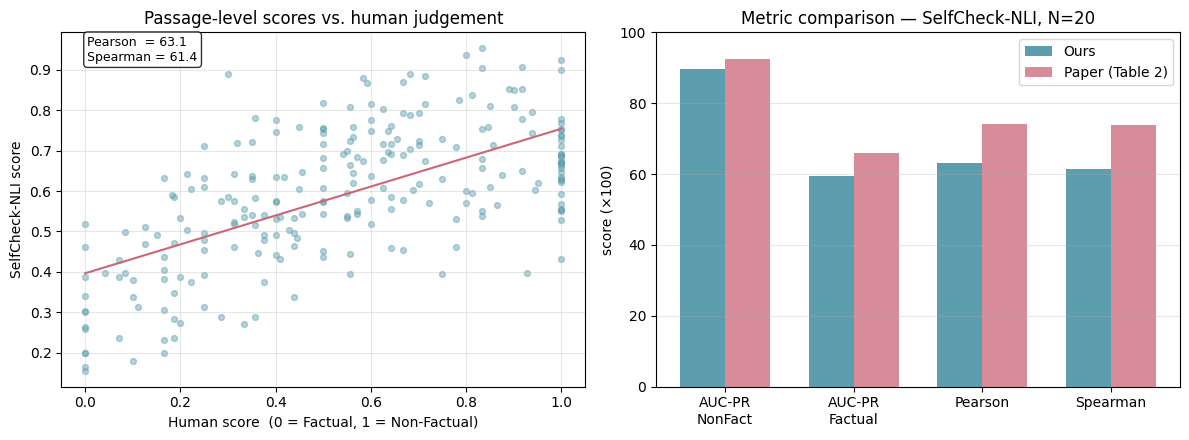

In [18]:
PAPER_REF = {'AUC_PR_NonFact': 92.50, 'AUC_PR_Factual': 66.08, 'Pearson': 74.14, 'Spearman': 73.78}
METRICS    = ['AUC_PR_NonFact', 'AUC_PR_Factual', 'Pearson', 'Spearman']
LABELS     = ['AUC-PR\nNonFact', 'AUC-PR\nFactual', 'Pearson', 'Spearman']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: passage-level scores vs human scores
ax = axes[0]
ax.scatter(passage_truths, passage_scores, alpha=0.45, s=18, color='#5c9ead')
m, b = np.polyfit(passage_truths, passage_scores, 1)
xs = np.linspace(0, 1, 100)
ax.plot(xs, m * xs + b, color='#cc6677', lw=1.5)
ax.set_xlabel('Human score  (0 = Factual, 1 = Non-Factual)')
ax.set_ylabel('SelfCheck-NLI score')
ax.set_title('Passage-level scores vs. human judgement')
ax.text(0.05, 0.92,
        f"Pearson  = {main['Pearson']:.1f}\nSpearman = {main['Spearman']:.1f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.grid(alpha=0.3)

# Right: ours vs paper reference
ax = axes[1]
x = np.arange(len(METRICS)); w = 0.35
ax.bar(x - w/2, [main[m]      for m in METRICS], w, label='Ours',            color='#5c9ead')
ax.bar(x + w/2, [PAPER_REF[m] for m in METRICS], w, label='Paper (Table 2)', color='#cc6677', alpha=0.75)
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylabel('score (\u00d7100)'); ax.set_ylim(0, 100)
ax.set_title('Metric comparison \u2014 SelfCheck-NLI, N=20')
ax.legend(); ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig('fig_nli_main.png', dpi=150)
plt.show()

## 5. Mini-experiment — does it transfer to GPT-2?

This mirrors the n-gram notebook’s transferability test on **identical generations**, so the two detectors can be compared directly. The official benchmark uses passages from `text-davinci-003` (≈175 B params). Question: does the same detector still work when the *generator* is `gpt2` (124 M params), four orders of magnitude smaller?

We pick three Wikipedia-style subjects — two well-known figures (`Marie Curie`, `Alan Turing`) and one entirely fabricated name (`Zorgblax Quintarius`) — prompt GPT-2 to write a one-paragraph biography, draw $N = 20$ stochastic samples on the same prompt, and score the response with SelfCheck-NLI.


In [19]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt2_tok = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tok.pad_token = gpt2_tok.eos_token
gpt2_gen = GPT2LMHeadModel.from_pretrained('gpt2').to(device).eval()

@torch.no_grad()
def gpt2_generate(prompt, temperature=1.0, max_new_tokens=80, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    inputs = gpt2_tok(prompt, return_tensors='pt').to(device)
    out = gpt2_gen.generate(
        **inputs, do_sample=True, temperature=temperature, top_p=0.95,
        max_new_tokens=max_new_tokens, pad_token_id=gpt2_tok.eos_token_id,
    )
    text = gpt2_tok.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return text.strip()

def split_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p for p in parts if len(p) > 5]


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [20]:
subjects = [
    'Marie Curie',          # well-known historical figure
    'Alan Turing',          # well-known
    'Zorgblax Quintarius',  # made-up name
]
N_gpt2 = 20

transfer = {}
for subj in subjects:
    prompt = f'{subj} was a'
    response = gpt2_generate(prompt, temperature=0.7, seed=0)
    samples  = [gpt2_generate(prompt, temperature=1.0, seed=s) for s in range(1, N_gpt2 + 1)]
    sents = split_sentences(response)
    if not sents:
        continue
    scores = selfcheck_nli(sents, samples)
    transfer[subj] = {'response': response, 'sentences': sents, 'scores': scores,
                      'mean': float(np.mean(scores))}
    print(f'\n=== {subj} (mean score = {transfer[subj]["mean"]:.2f}) ===')
    print(prompt + ' ' + response[:300])
    for s, sc in zip(sents, scores):
        print(f'  [{sc:4.2f}] {s[:100]}')



=== Marie Curie (mean score = 0.92) ===
Marie Curie was a former top aide to Rep. Peter King, R-N.Y.

Mr. Trump's campaign announced on Thursday that he had hired former Florida Gov. Jeb Bush to run his presidential campaign. The news was reported by Politico.

Mr. Trump is one of four presidential candidates who has endorsed Mr. Bush, who has said he will
  [0.85] former top aide to Rep.
  [0.92] Peter King, R-N.Y.
  [0.91] Trump's campaign announced on Thursday that he had hired former Florida Gov.
  [0.94] Jeb Bush to run his presidential campaign.
  [0.95] The news was reported by Politico.
  [0.97] Trump is one of four presidential candidates who has endorsed Mr.
  [0.92] Bush, who has said he will seek a third term in the White House.

=== Alan Turing (mean score = 0.78) ===
Alan Turing was a former top executive of Turing Pharmaceuticals, where he was awarded a Nobel Prize for his work on drugs.

He was charged with conspiracy to commit bribery and conspiring to defraud the gov

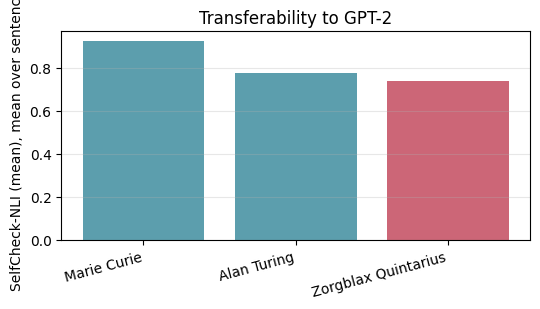

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
names = list(transfer.keys())
means = [transfer[s]['mean'] for s in names]
colors = ['#5c9ead', '#5c9ead', '#cc6677']
ax.bar(range(len(names)), means, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('SelfCheck-NLI (mean), mean over sentences')
ax.set_title('Transferability to GPT-2')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig('fig_nli_gpt2_transfer.png', dpi=150); plt.show()
